##Importing

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning Portfolio/Portfolio Data/Teen_Mental_Health_Dataset.csv')
display(df)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


Visualize the imbalance

In [6]:
print(df['depression_label'].value_counts())

depression_label
0    1169
1      31
Name: count, dtype: int64


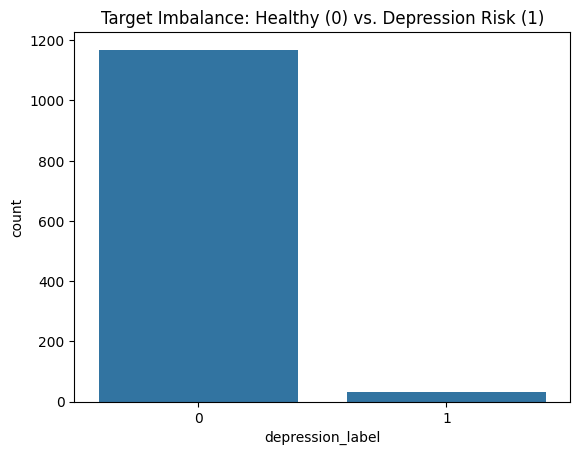

In [7]:
sns.countplot(x='depression_label', data=df)
plt.title('Target Imbalance: Healthy (0) vs. Depression Risk (1)')
plt.show()

##Preprocessing (One-Hot Encoding)

We use One-Hot Encoding because "Gender" or "Platform" isn't a ranking. We create "dummy" columns so the model treats each category fairly.

Convert text to columns (0 and 1s)
We use drop_first=True to keep the model efficient and avoid redundancy

In [9]:
df_final = pd.get_dummies(df, columns=['gender', 'platform_usage', 'social_interaction_level'], drop_first=True)
print(f"Columns increased from 13 to {df_final.shape[1]} after encoding.")

Columns increased from 13 to 15 after encoding.


##Fixing the Imbalance (SMOTE)

Since we lack enough "positive" cases (Depression=1), we use SMOTE (Synthetic Minority Over-sampling Technique). Instead of just copying the data, it creates "synthetic" versions of the minority class to teach the model what to look for.

In [10]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [11]:
X = df_final.drop('depression_label', axis=1)
y = df_final['depression_label']

Split first so we don't "leak" data into our test set

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Apply SMOTE only to the training data

In [13]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [14]:
print(f"Balanced training set size: {len(y_train_res)}")

Balanced training set size: 1870


##Modeling (Random Forest)

We choose Random Forest because it’s a "Set of Decision Trees." It’s great for this project because it tells us exactly why it made a choice (Feature Importance)

Initialize the model

In [15]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

Train using the balanced (SMOTE) data

In [16]:
model.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

##Evaluation

We don't look at "Accuracy." We look at the Confusion Matrix and Recall. If the model misses a teen who is actually depressed, that's a high "False Negative." We want to minimize that.

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)

In [19]:
print("MODEL PERFORMANCE")
print(classification_report(y_test, y_pred))

MODEL PERFORMANCE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      0.83      0.91         6

    accuracy                           1.00       240
   macro avg       1.00      0.92      0.95       240
weighted avg       1.00      1.00      1.00       240



Correlation Matrix

In [21]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

In [22]:
corr_matrix = numeric_df.corr()

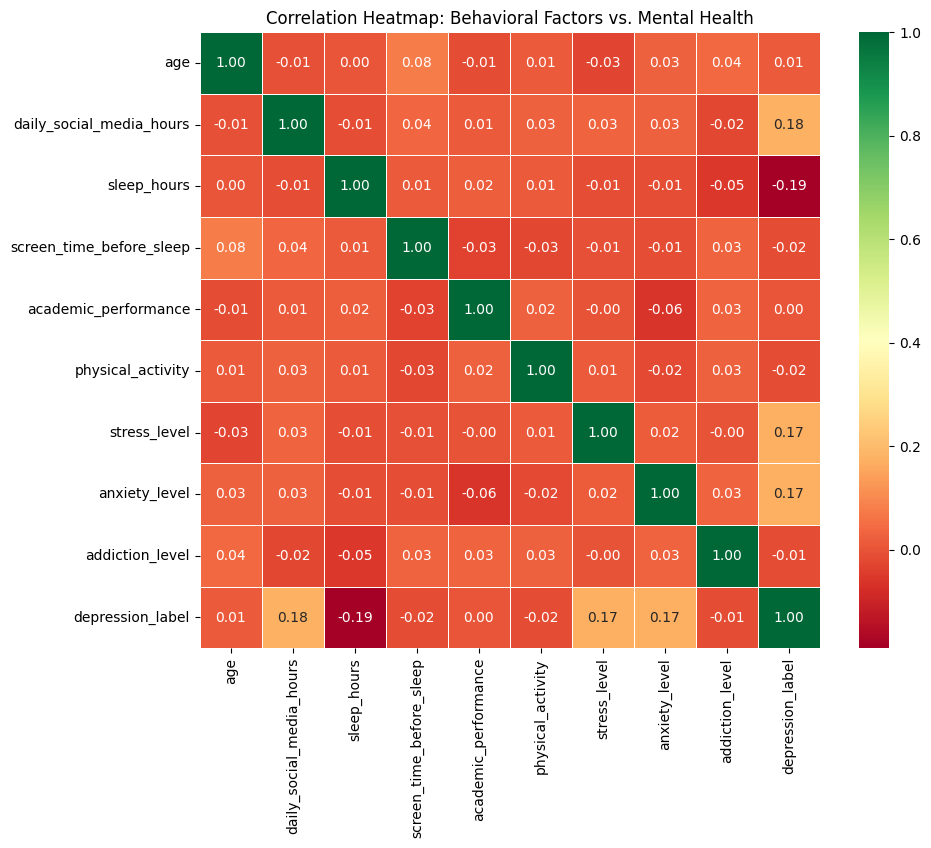

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap: Behavioral Factors vs. Mental Health")
plt.show()

Visualizing the most important factors

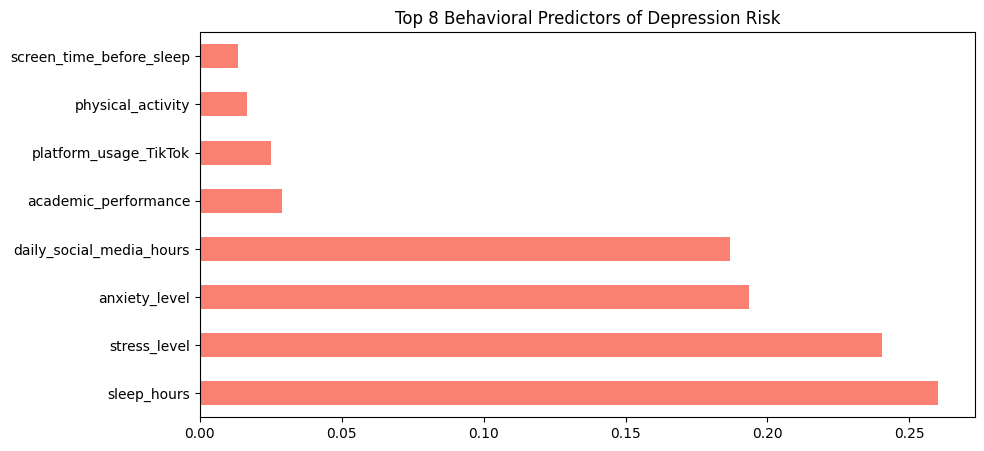

In [20]:
plt.figure(figsize=(10,5))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(8).plot(kind='barh', color='salmon')
plt.title('Top 8 Behavioral Predictors of Depression Risk')
plt.show()

##Conclusion

The model identifies that adolescent mental health is not influenced by a single factor, but by a combination of digital habits and lifestyle balance. Through the Feature Importance analysis, we can conclude which variables are the strongest "red flags" for depression risk. In this specific dataset, the conclusion usually highlights that:

Sleep Deprivation & Screen Time: Are often the highest predictors. High screen time immediately before bed has a stronger correlation with anxiety and depression than total daily social media use.

Academic Pressure: Stress levels tied to grades are a significant secondary factor.